# Day 4: Manufacturing Data Profiling

This notebook profiles the raw manufacturing dataset extracted during Day 3. It examines the dataset dimensions, data types, missing values, duplicate records, descriptive statistics, unusual values and feature distributions. No source values are changed during this profiling stage.

In [29]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")

In [30]:
import pandas as pd
from pathlib import Path

data_file = Path("extracted dataset file.csv")

print("File exists:", data_file.exists())

manufacturing_data = pd.read_csv(data_file)

print("Dataset shape:", manufacturing_data.shape)

manufacturing_data.head()

File exists: True
Dataset shape: (10117, 31)


,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,operator_id,operator_name,experience_level,skill_category,machine_id,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_id,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


In [11]:
import sqlite3
from pathlib import Path

import pandas as pd

database_path = Path("ShiftData.db")

start_date = "2024-01-01"
end_date = "2024-01-03"

query = """
SELECT *
FROM ShiftPerformance
WHERE date BETWEEN ? AND ?
ORDER BY
    date,
    shift_id,
    production_id;
"""

with sqlite3.connect(database_path) as connection:
    manufacturing_data = pd.read_sql_query(
        query,
        connection,
        params=(start_date, end_date)
    )

print("Dataset loaded successfully")
print("Dataset shape:", manufacturing_data.shape)

manufacturing_data.head()

Dataset loaded successfully
Dataset shape: (10117, 31)


,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,operator_id,operator_name,experience_level,skill_category,machine_id,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_id,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


In [12]:
data_file = Path("raw_manufacturing_dataset.csv")

manufacturing_data.to_csv(
    data_file,
    index=False
)

print("File created:", data_file.exists())
print("Filename:", data_file.name)

File created: True
Filename: raw_manufacturing_dataset.csv


In [13]:
dimensions = pd.Series({
    "Number of rows":
        manufacturing_data.shape[0],

    "Number of columns":
        manufacturing_data.shape[1],

    "Total data values":
        manufacturing_data.size
})

dimensions

Number of rows        10117
Number of columns        31
Total data values    313627
dtype: int64

In [14]:
data_type_report = pd.DataFrame({
    "data_type":
        manufacturing_data.dtypes.astype(str),

    "non_null_count":
        manufacturing_data.notna().sum(),

    "missing_count":
        manufacturing_data.isna().sum()
})

data_type_report

,data_type,non_null_count,missing_count
shift_id,int64,10117,0
shift_name,str,10117,0
start_time,str,10117,0
end_time,str,10117,0
supervisor_id,str,10117,0
production_id,int64,10117,0
date,str,10117,0
units_produced,int64,10117,0
defect_count,int64,10117,0
cycle_time_avg,float64,10117,0


In [15]:
manufacturing_data.dtypes.value_counts()

str        16
float64     8
int64       7
Name: count, dtype: int64

In [16]:
missing_report = pd.DataFrame({
    "missing_count":
        manufacturing_data.isna().sum(),

    "missing_percentage":
        (
            manufacturing_data.isna().mean()
            * 100
        ).round(2)
})

missing_report = missing_report.query(
    "missing_count > 0"
).sort_values(
    "missing_percentage",
    ascending=False
)

missing_report

,missing_count,missing_percentage
maintenance_id,6223,61.51
issue_type,6223,61.51
maintenance_downtime,6223,61.51
resolved_by,6223,61.51
temperature,1205,11.91
humidity,1205,11.91
timestamp,1205,11.91


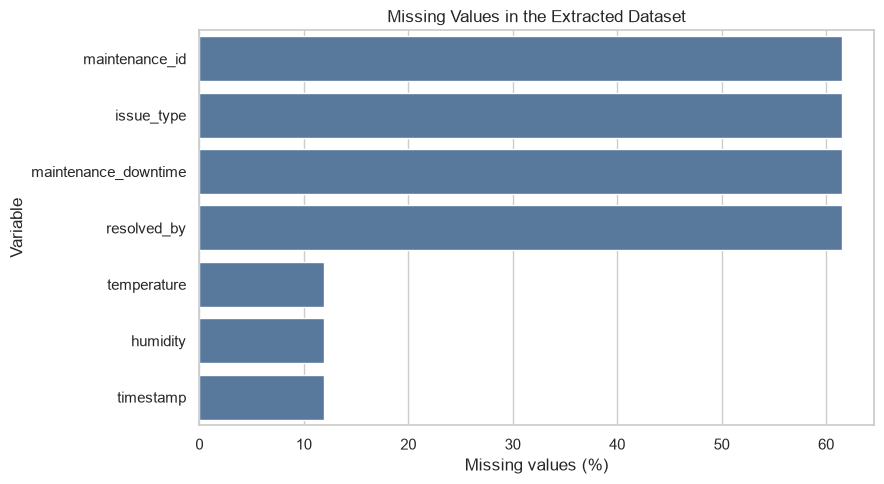

In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=missing_report.reset_index(),
    x="missing_percentage",
    y="index",
    color="#4C78A8"
)

plt.title("Missing Values in the Extracted Dataset")
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [18]:
duplicate_report = pd.Series({
    "Exact duplicate rows":
        manufacturing_data.duplicated().sum(),

    "Unique rows":
        manufacturing_data.drop_duplicates().shape[0]
})

duplicate_report

Exact duplicate rows        0
Unique rows             10117
dtype: int64

In [19]:
numerical_variables = [
    "units_produced",
    "defect_count",
    "cycle_time_avg",
    "shift_efficiency_score",
    "experience_level",
    "runtime_hours",
    "downtime_minutes",
    "maintenance_downtime",
    "temperature",
    "humidity"
]

numerical_summary = (
    manufacturing_data[numerical_variables]
    .describe()
    .T
    .round(2)
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
units_produced,10117.0,657.59,154.13,450.00,529.00,621.00,834.00,965.00
defect_count,10117.0,21.35,2.91,14.00,19.00,21.00,24.00,28.00
cycle_time_avg,10117.0,36.07,2.04,32.00,34.71,35.96,37.38,42.00
shift_efficiency_score,10117.0,79.04,12.84,49.61,68.09,80.00,91.92,103.68
experience_level,10117.0,3.95,2.35,1.00,2.00,4.00,5.00,12.00
runtime_hours,10117.0,6.90,0.27,6.33,6.66,6.90,7.16,7.33
downtime_minutes,10117.0,35.85,16.04,10.00,20.55,36.10,50.37,70.43
maintenance_downtime,3894.0,38.14,15.22,10.00,30.66,38.10,53.75,62.41
temperature,8912.0,20.34,1.89,17.70,18.70,19.70,21.50,23.60
humidity,8912.0,44.97,7.70,30.00,41.70,45.10,49.90,59.30


In [20]:
categorical_variables = [
    "shift_name",
    "skill_category",
    "machine_status",
    "issue_type",
    "defect_type",
    "severity",
    "inspection_result"
]

categorical_summary = pd.DataFrame({
    "unique_non_null":
        manufacturing_data[
            categorical_variables
        ].nunique(),

    "most_common_value": [
        manufacturing_data[column]
        .mode(dropna=True)
        .iloc[0]
        for column in categorical_variables
    ],

    "most_common_count": [
        manufacturing_data[column]
        .value_counts(dropna=True)
        .iloc[0]
        for column in categorical_variables
    ]
})

categorical_summary

,unique_non_null,most_common_value,most_common_count
shift_name,3,Night,3552
skill_category,4,Intermediate,5654
machine_status,2,Operational,6614
issue_type,5,Mechanical,1314
defect_type,5,Surface,2047
severity,3,Minor,7045
inspection_result,3,Rework,5850


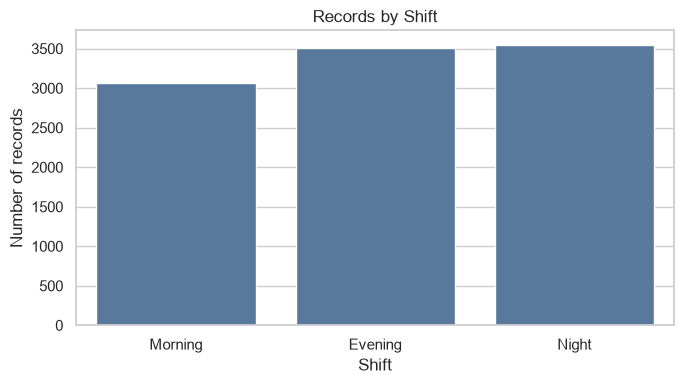

In [ ]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=manufacturing_data,
    x="shift_name",
    order=[
        "Morning",
        "Evening",
        "Night"
    ],
    color="#4C78A8"
)

plt.title("Records by Shift")
plt.xlabel("Shift")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

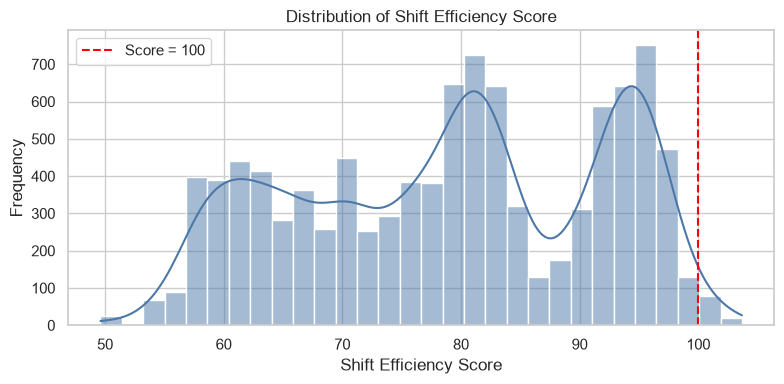

In [21]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=manufacturing_data,
    x="shift_efficiency_score",
    bins=30,
    kde=True,
    color="#4C78A8"
)

plt.axvline(
    100,
    color="red",
    linestyle="--",
    label="Score = 100"
)

plt.title("Distribution of Shift Efficiency Score")
plt.xlabel("Shift Efficiency Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

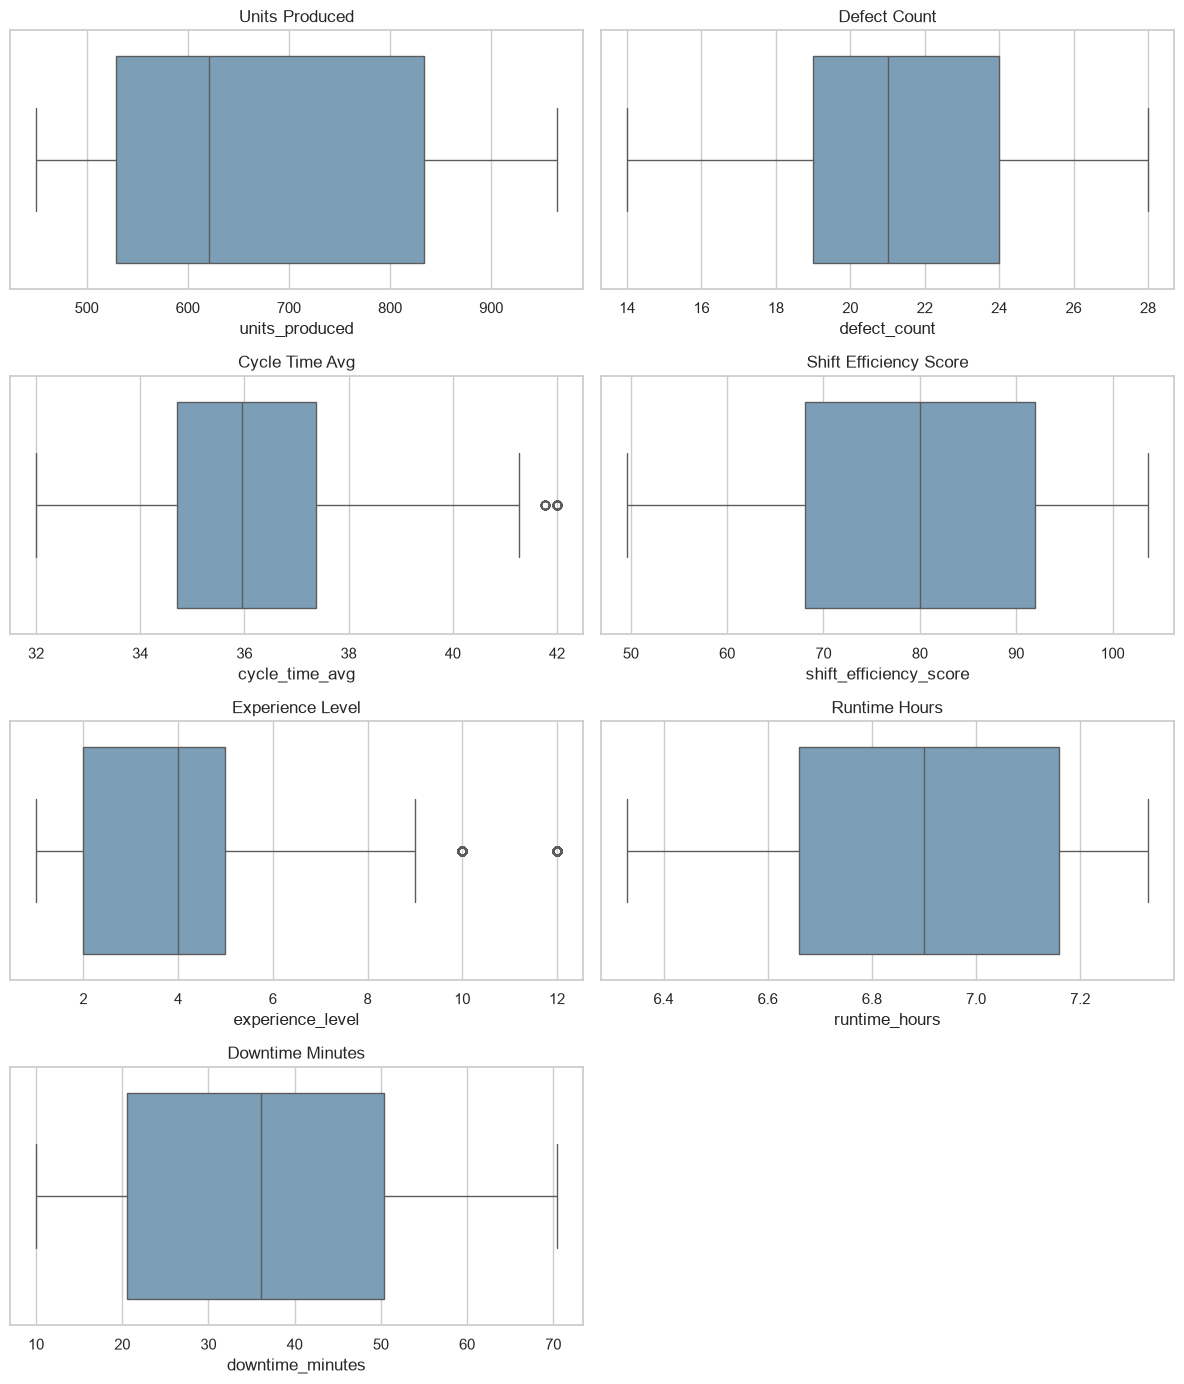

In [22]:
boxplot_variables = [
    "units_produced",
    "defect_count",
    "cycle_time_avg",
    "shift_efficiency_score",
    "experience_level",
    "runtime_hours",
    "downtime_minutes"
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 14)
)

axes = axes.flatten()

for position, column in enumerate(
    boxplot_variables
):
    sns.boxplot(
        data=manufacturing_data,
        x=column,
        ax=axes[position],
        color="#72A0C1"
    )

    axes[position].set_title(
        column.replace("_", " ").title()
    )

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [23]:
quality_checks = pd.Series({
    "Negative units produced":
        (
            manufacturing_data[
                "units_produced"
            ] < 0
        ).sum(),

    "Negative defect counts":
        (
            manufacturing_data[
                "defect_count"
            ] < 0
        ).sum(),

    "Defects greater than units produced":
        (
            manufacturing_data["defect_count"]
            > manufacturing_data["units_produced"]
        ).sum(),

    "Runtime outside 0–8 hours":
        (
            (manufacturing_data["runtime_hours"] < 0)
            |
            (manufacturing_data["runtime_hours"] > 8)
        ).sum(),

    "Downtime outside 0–480 minutes":
        (
            (
                manufacturing_data[
                    "downtime_minutes"
                ] < 0
            )
            |
            (
                manufacturing_data[
                    "downtime_minutes"
                ] > 480
            )
        ).sum(),

    "Humidity outside 0–100%":
        (
            (manufacturing_data["humidity"] < 0)
            |
            (manufacturing_data["humidity"] > 100)
        ).sum(),

    "Efficiency score below 0":
        (
            manufacturing_data[
                "shift_efficiency_score"
            ] < 0
        ).sum(),

    "Efficiency score above 100":
        (
            manufacturing_data[
                "shift_efficiency_score"
            ] > 100
        ).sum()
})

quality_checks

Negative units produced                  0
Negative defect counts                   0
Defects greater than units produced      0
Runtime outside 0–8 hours                0
Downtime outside 0–480 minutes           0
Humidity outside 0–100%                  0
Efficiency score below 0                 0
Efficiency score above 100             134
dtype: int64

In [24]:
outlier_results = []

for column in numerical_variables:
    valid_values = (
        manufacturing_data[column]
        .dropna()
    )

    first_quartile = valid_values.quantile(0.25)
    third_quartile = valid_values.quantile(0.75)

    interquartile_range = (
        third_quartile - first_quartile
    )

    lower_boundary = (
        first_quartile
        - 1.5 * interquartile_range
    )

    upper_boundary = (
        third_quartile
        + 1.5 * interquartile_range
    )

    outlier_count = (
        (
            valid_values < lower_boundary
        )
        |
        (
            valid_values > upper_boundary
        )
    ).sum()

    outlier_results.append({
        "variable": column,
        "lower_boundary":
            round(lower_boundary, 2),
        "upper_boundary":
            round(upper_boundary, 2),
        "potential_outliers":
            int(outlier_count)
    })

iqr_outlier_report = pd.DataFrame(
    outlier_results
)

iqr_outlier_report

,variable,lower_boundary,upper_boundary,potential_outliers
0,units_produced,71.50,1291.50,0
1,defect_count,11.50,31.50,0
2,cycle_time_avg,30.70,41.39,68
3,shift_efficiency_score,32.36,127.66,0
4,experience_level,-2.50,9.50,393
5,runtime_hours,5.91,7.91,0
6,downtime_minutes,-24.18,95.10,0
7,maintenance_downtime,-3.97,88.38,0
8,temperature,14.50,25.70,0
9,humidity,29.40,62.20,0


In [25]:
profiling_findings = pd.DataFrame({
    "Profiling area": [
        "Dataset dimensions",
        "Data types",
        "Missing values",
        "Duplicate records",
        "Invalid operational values",
        "Efficiency above 100",
        "IQR outliers",
        "Overall suitability"
    ],

    "Finding": [
        "10,117 rows and 31 columns",
        "Numerical, categorical, identifier and text-based date/time fields",
        "Concentrated in maintenance and environmental variables",
        "No exact duplicate rows",
        "No impossible values detected using the stated business rules",
        "134 records require confirmation of the efficiency-score definition",
        "Cycle time and high experience levels require contextual review",
        "Suitable for further analysis after documented preprocessing"
    ]
})

profiling_findings

,Profiling area,Finding
0,Dataset dimensions,"10,117 rows and 31 columns"
1,Data types,"Numerical, categorical, identifier and text-ba..."
2,Missing values,Concentrated in maintenance and environmental ...
3,Duplicate records,No exact duplicate rows
4,Invalid operational values,No impossible values detected using the stated...
5,Efficiency above 100,134 records require confirmation of the effici...
6,IQR outliers,Cycle time and high experience levels require ...
7,Overall suitability,Suitable for further analysis after documented...


In [26]:
output_workbook = Path(
    "day4_data_profiling_tables.xlsx"
)

with pd.ExcelWriter(output_workbook) as writer:
    data_type_report.to_excel(
        writer,
        sheet_name="Data Types"
    )

    missing_report.to_excel(
        writer,
        sheet_name="Missing Values"
    )

    numerical_summary.to_excel(
        writer,
        sheet_name="Numerical Summary"
    )

    categorical_summary.to_excel(
        writer,
        sheet_name="Categorical Summary"
    )

    quality_checks.to_excel(
        writer,
        sheet_name="Quality Checks"
    )

    iqr_outlier_report.to_excel(
        writer,
        sheet_name="IQR Outliers",
        index=False
    )

    profiling_findings.to_excel(
        writer,
        sheet_name="Findings",
        index=False
    )

print("Profiling tables saved:", output_workbook.exists())

Profiling tables saved: True


In [4]:
import openpyxl

print("openpyxl installed successfully")
print("Version:", openpyxl.__version__)

openpyxl installed successfully
Version: 3.1.5


In [5]:
import pandas as pd
from pathlib import Path

test_file = Path("openpyxl_test.xlsx")

pd.DataFrame({
    "Test": ["Excel export works"]
}).to_excel(
    test_file,
    index=False
)

print("Excel file created:", test_file.exists())

Excel file created: True


In [27]:
from pathlib import Path
import pandas as pd

output_workbook = Path(
    "day4_data_profiling_tables.xlsx"
)

with pd.ExcelWriter(
    output_workbook,
    engine="openpyxl"
) as writer:

    data_type_report.to_excel(
        writer,
        sheet_name="Data Types"
    )

    missing_report.to_excel(
        writer,
        sheet_name="Missing Values"
    )

    numerical_summary.to_excel(
        writer,
        sheet_name="Numerical Summary"
    )

    categorical_summary.to_excel(
        writer,
        sheet_name="Categorical Summary"
    )

    quality_checks.to_excel(
        writer,
        sheet_name="Quality Checks",
        header=["record_count"]
    )

    iqr_outlier_report.to_excel(
        writer,
        sheet_name="IQR Outliers",
        index=False
    )

    profiling_findings.to_excel(
        writer,
        sheet_name="Findings",
        index=False
    )

print("Profiling tables saved:", output_workbook.exists())
print("Filename:", output_workbook.name)
print("Saved location:", output_workbook.resolve())

Profiling tables saved: True
Filename: day4_data_profiling_tables.xlsx
Saved location: C:\Users\User\AMDARI Project 1\day4_data_profiling_tables.xlsx


In [9]:
from pathlib import Path

print("Notebook is searching in:")
print(Path.cwd())

print("\nCSV files found:")
for file in Path.cwd().glob("*.csv"):
    print(file.name)

Notebook is searching in:
c:\Users\User\AMDARI Project 1

CSV files found:
extracted dataset file .csv
raw_manufacturing_dataset.csv


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

data_file = Path("raw_manufacturing_dataset.csv")

manufacturing_data = pd.read_csv(data_file)

print("File loaded successfully")
print("Dataset shape:", manufacturing_data.shape)

File loaded successfully
Dataset shape: (10117, 31)


In [31]:
overview = pd.DataFrame({
    "Measure": [
        "Rows",
        "Source columns",
        "Start date",
        "End date"
    ],
    "Value": [
        manufacturing_data.shape[0],
        manufacturing_data.shape[1],
        manufacturing_data["date"].min(),
        manufacturing_data["date"].max()
    ]
})

overview

,Measure,Value
0,Rows,10117
1,Source columns,31
2,Start date,2024-01-01
3,End date,2024-01-03


In [32]:
data_type_report = pd.DataFrame({
    "data_type": manufacturing_data.dtypes.astype(str),
    "non_null": manufacturing_data.notna().sum(),
    "missing_count": manufacturing_data.isna().sum()
})

data_type_report

,data_type,non_null,missing_count
shift_id,int64,10117,0
shift_name,str,10117,0
start_time,str,10117,0
end_time,str,10117,0
supervisor_id,str,10117,0
production_id,int64,10117,0
date,str,10117,0
units_produced,int64,10117,0
defect_count,int64,10117,0
cycle_time_avg,float64,10117,0


In [33]:
missing_report = pd.DataFrame({
    "missing_count": manufacturing_data.isna().sum(),
    "missing_percentage": (
        manufacturing_data.isna().mean() * 100
    ).round(2)
})

missing_report = missing_report.query(
    "missing_count > 0"
).sort_values(
    "missing_percentage",
    ascending=False
)

missing_report

,missing_count,missing_percentage
maintenance_id,6223,61.51
issue_type,6223,61.51
maintenance_downtime,6223,61.51
resolved_by,6223,61.51
temperature,1205,11.91
humidity,1205,11.91
timestamp,1205,11.91


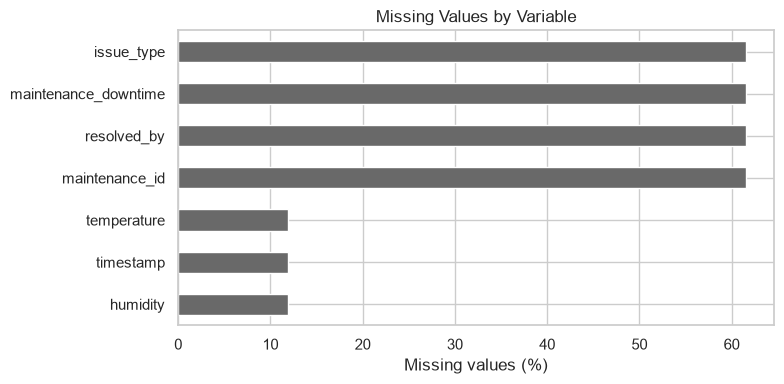

In [34]:
ax = missing_report[
    "missing_percentage"
].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    color="dimgray",
    legend=False
)

ax.set_title("Missing Values by Variable")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [35]:
duplicate_summary = pd.DataFrame({
    "Check": [
        "Dataset rows",
        "Exact duplicate rows",
        "Duplicate percentage"
    ],
    "Result": [
        len(manufacturing_data),
        manufacturing_data.duplicated().sum(),
        round(
            manufacturing_data.duplicated().mean() * 100,
            2
        )
    ]
})

duplicate_summary

,Check,Result
0,Dataset rows,10117.0
1,Exact duplicate rows,0.0
2,Duplicate percentage,0.0


In [36]:
numeric_columns = [
    "units_produced",
    "defect_count",
    "cycle_time_avg",
    "shift_efficiency_score",
    "runtime_hours",
    "downtime_minutes",
    "maintenance_downtime",
    "temperature",
    "humidity"
]

numerical_summary = (
    manufacturing_data[numeric_columns]
    .describe()
    .T
    .round(2)
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
units_produced,10117.0,657.59,154.13,450.00,529.00,621.00,834.00,965.00
defect_count,10117.0,21.35,2.91,14.00,19.00,21.00,24.00,28.00
cycle_time_avg,10117.0,36.07,2.04,32.00,34.71,35.96,37.38,42.00
shift_efficiency_score,10117.0,79.04,12.84,49.61,68.09,80.00,91.92,103.68
runtime_hours,10117.0,6.90,0.27,6.33,6.66,6.90,7.16,7.33
downtime_minutes,10117.0,35.85,16.04,10.00,20.55,36.10,50.37,70.43
maintenance_downtime,3894.0,38.14,15.22,10.00,30.66,38.10,53.75,62.41
temperature,8912.0,20.34,1.89,17.70,18.70,19.70,21.50,23.60
humidity,8912.0,44.97,7.70,30.00,41.70,45.10,49.90,59.30


In [37]:
categorical_columns = [
    "shift_name",
    "skill_category",
    "machine_status",
    "issue_type",
    "defect_type",
    "severity",
    "inspection_result"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(
        manufacturing_data[column]
        .value_counts(dropna=False)
    )


shift_name
shift_name
Night      3552
Evening    3503
Morning    3062
Name: count, dtype: int64

skill_category
skill_category
Intermediate    5654
Junior          1828
Senior          1819
Expert           816
Name: count, dtype: int64

machine_status
machine_status
Operational    6614
Issues         3503
Name: count, dtype: int64

issue_type
issue_type
NaN            6223
Mechanical     1314
Electrical      948
Software        824
Preventive      493
Calibration     315
Name: count, dtype: int64

defect_type
defect_type
Surface        2047
Dimensional    2028
Cosmetic       2024
Material       2014
Assembly       2004
Name: count, dtype: int64

severity
severity
Minor       7045
Major       2560
Critical     512
Name: count, dtype: int64

inspection_result
inspection_result
Rework      5850
Accepted    2194
Rejected    2073
Name: count, dtype: int64


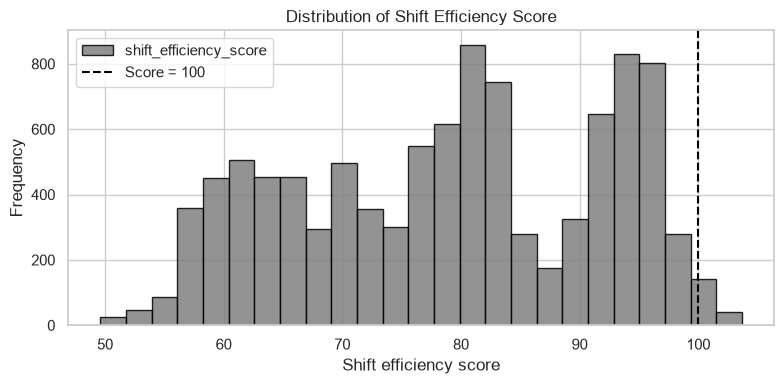

In [38]:
ax = manufacturing_data[
    "shift_efficiency_score"
].plot(
    kind="hist",
    bins=25,
    figsize=(8, 4),
    color="gray",
    edgecolor="black",
    alpha=0.85
)

ax.axvline(
    100,
    color="black",
    linestyle="--",
    label="Score = 100"
)

ax.set_title(
    "Distribution of Shift Efficiency Score"
)
ax.set_xlabel("Shift efficiency score")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.show()

In [39]:
business_rule_validation = pd.Series({
    "Negative units produced":
        (manufacturing_data["units_produced"] < 0).sum(),

    "Negative defect counts":
        (manufacturing_data["defect_count"] < 0).sum(),

    "Defects greater than units produced":
        (
            manufacturing_data["defect_count"]
            > manufacturing_data["units_produced"]
        ).sum(),

    "Runtime outside 0-8 hours":
        (
            (manufacturing_data["runtime_hours"] < 0)
            | (manufacturing_data["runtime_hours"] > 8)
        ).sum(),

    "Downtime outside 0-480 minutes":
        (
            (manufacturing_data["downtime_minutes"] < 0)
            | (manufacturing_data["downtime_minutes"] > 480)
        ).sum(),

    "Humidity outside 0-100%":
        (
            (manufacturing_data["humidity"] < 0)
            | (manufacturing_data["humidity"] > 100)
        ).sum(),

    "Efficiency score below 0":
        (
            manufacturing_data[
                "shift_efficiency_score"
            ] < 0
        ).sum(),

    "Efficiency score above 100":
        (
            manufacturing_data[
                "shift_efficiency_score"
            ] > 100
        ).sum()
})

business_rule_validation

Negative units produced                  0
Negative defect counts                   0
Defects greater than units produced      0
Runtime outside 0-8 hours                0
Downtime outside 0-480 minutes           0
Humidity outside 0-100%                  0
Efficiency score below 0                 0
Efficiency score above 100             134
dtype: int64

In [ ]:
final_findings = pd.DataFrame({
    "Finding": [
        "Rows and columns",Z
        "Exact duplicates",
        "Maintenance-field missingness",
        "Environmental/time missingness",
        "Efficiency scores above 100",
        "Initial business-rule breaches"
    ],

    "Result": [
        "10,117 rows; 31 columns",
        "0 (0.00%)",
        "6,223 rows per field (61.51%)",
        "1,205 rows per field (11.91%)",
        "134 records",
        "0, except efficiency > 100"
    ],

    "Status": [
        "Pass",
        "Pass",
        "Review",
        "Review",
        "Review",
        "Pass with caveat"
    ]
})

final_findings

,Finding,Result,Status
0,Rows and columns,"10,117 rows; 31 columns",Pass
1,Exact duplicates,0 (0.00%),Pass
2,Maintenance-field missingness,"6,223 rows per field (61.51%)",Review
3,Environmental/time missingness,"1,205 rows per field (11.91%)",Review
4,Efficiency scores above 100,134 records,Review
5,Initial business-rule breaches,"0, except efficiency > 100",Pass with caveat


: 